In [2]:
pip install scikit-learn

   ---------------------------------------- 0.0/11.1 MB ? eta -:--:--
   ---- ----------------------------------- 1.3/11.1 MB 14.2 MB/s eta 0:00:01
   ---------------- ----------------------- 4.5/11.1 MB 14.8 MB/s eta 0:00:01
   ------------------ --------------------- 5.2/11.1 MB 11.2 MB/s eta 0:00:01
   ----------------------- ---------------- 6.6/11.1 MB 9.2 MB/s eta 0:00:01
   -------------------------- ------------- 7.3/11.1 MB 8.6 MB/s eta 0:00:01
   ---------------------------------------- 11.1/11.1 MB 10.4 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix
import logging
from typing import Tuple
from sklearn.base import BaseEstimator
import time
#from xgboost import XGBClassifier
import scipy.stats

In [4]:
df = pd.read_csv (r'Telecom_Customer_Churn.csv')
df.isna().any().any() # Confirms that there are no missing values in our dataset which is a relief

np.False_

- Diving variables into categorical and also numeric
- Dummifying categorical variables, keeping customerID for the future easier merging

In [5]:
categorical_var = df.drop([ 'tenure', 'MonthlyCharges', 'TotalCharges'], axis = 1)   
customer_id = categorical_var[['customerID']]
categorical_var_excluded = categorical_var.drop('customerID', axis=1)
categorical_var_dummies = pd.get_dummies(categorical_var_excluded, drop_first=True)
categorical_var_dummies = pd.concat([customer_id, categorical_var_dummies], axis=1)
numeric_var = df[['customerID','tenure', 'MonthlyCharges', 'TotalCharges']]
categorical_var_dummies
conv_df = pd.merge(categorical_var_dummies, numeric_var, on= 'customerID', how='left')
conv_df.head(5)

,customerID,SeniorCitizen,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,...,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes,tenure,MonthlyCharges,TotalCharges
0,7590-VHVEG,0,False,True,False,False,True,False,False,False,...,False,False,True,False,True,False,False,1,29.85,29.85
1,5575-GNVDE,0,True,False,False,True,False,False,False,False,...,True,False,False,False,False,True,False,34,56.95,1889.5
2,3668-QPYBK,0,True,False,False,True,False,False,False,False,...,False,False,True,False,False,True,True,2,53.85,108.15
3,7795-CFOCW,0,True,False,False,False,True,False,False,False,...,True,False,False,False,False,False,False,45,42.30,1840.75
4,9237-HQITU,0,False,False,False,True,False,False,True,False,...,False,False,True,False,True,False,True,2,70.70,151.65


- Converted dataframe has 32 columns due to created dummy variables
- We proceed to inspect our numeric variables and their frequency distributions

In [6]:
numeric_var = numeric_var.drop('customerID', axis = 1)

In [7]:
numeric_var.isnull().value_counts()

tenure  MonthlyCharges  TotalCharges
False   False           False           7043
Name: count, dtype: int64

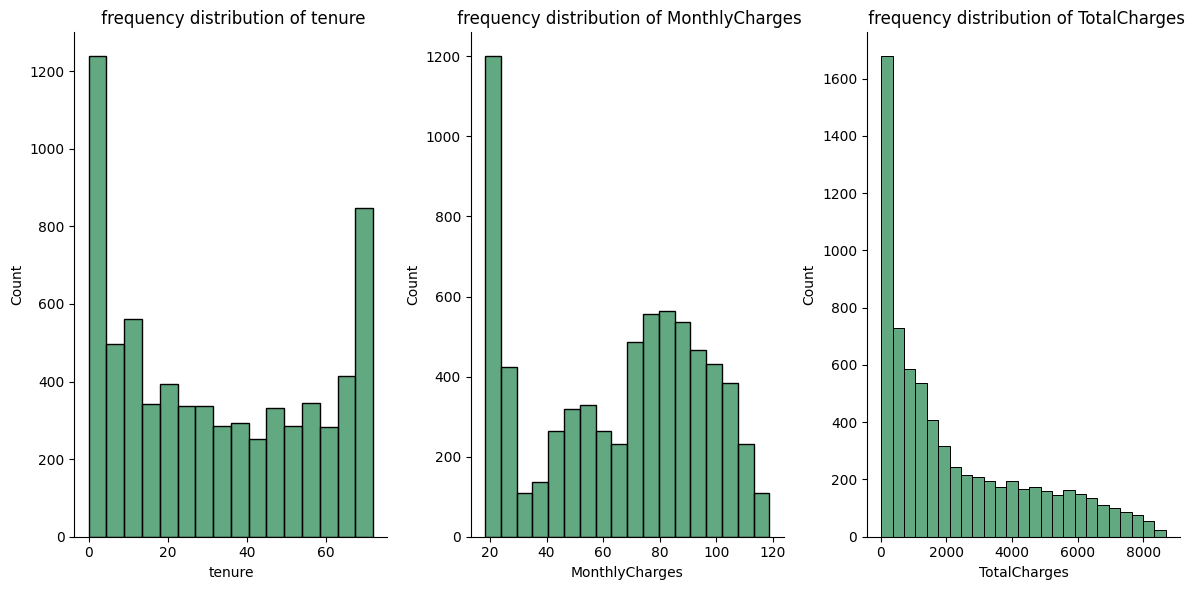

In [8]:
numeric_var['TotalCharges'] = pd.to_numeric(numeric_var['TotalCharges'], errors='coerce')
fig, axs = plt.subplots(1, 3, figsize =(12, 6))
for idx, column in enumerate(numeric_var.columns):
    sns.histplot(numeric_var[column], color = 'seagreen', ax=axs[idx])
    axs[idx].spines['top'].set_visible(False)
    axs[idx].spines['right'].set_visible(False)
    axs[idx].set_title(f" frequency distribution of {column}")
plt.tight_layout()
plt.show() 

In [9]:
logged_numeric_var = np.log1p(numeric_var)
logged_numeric_var = logged_numeric_var.fillna(0)
logged_numeric_var.isna().any().any()

np.False_

In [10]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
scaled_var = logged_numeric_var[['tenure', 'MonthlyCharges', 'TotalCharges']]
scaler = StandardScaler()
scaled_features = scaler.fit_transform(logged_numeric_var[numeric_cols])
scaled_numeric_var = pd.DataFrame(scaled_features, columns=numeric_cols)

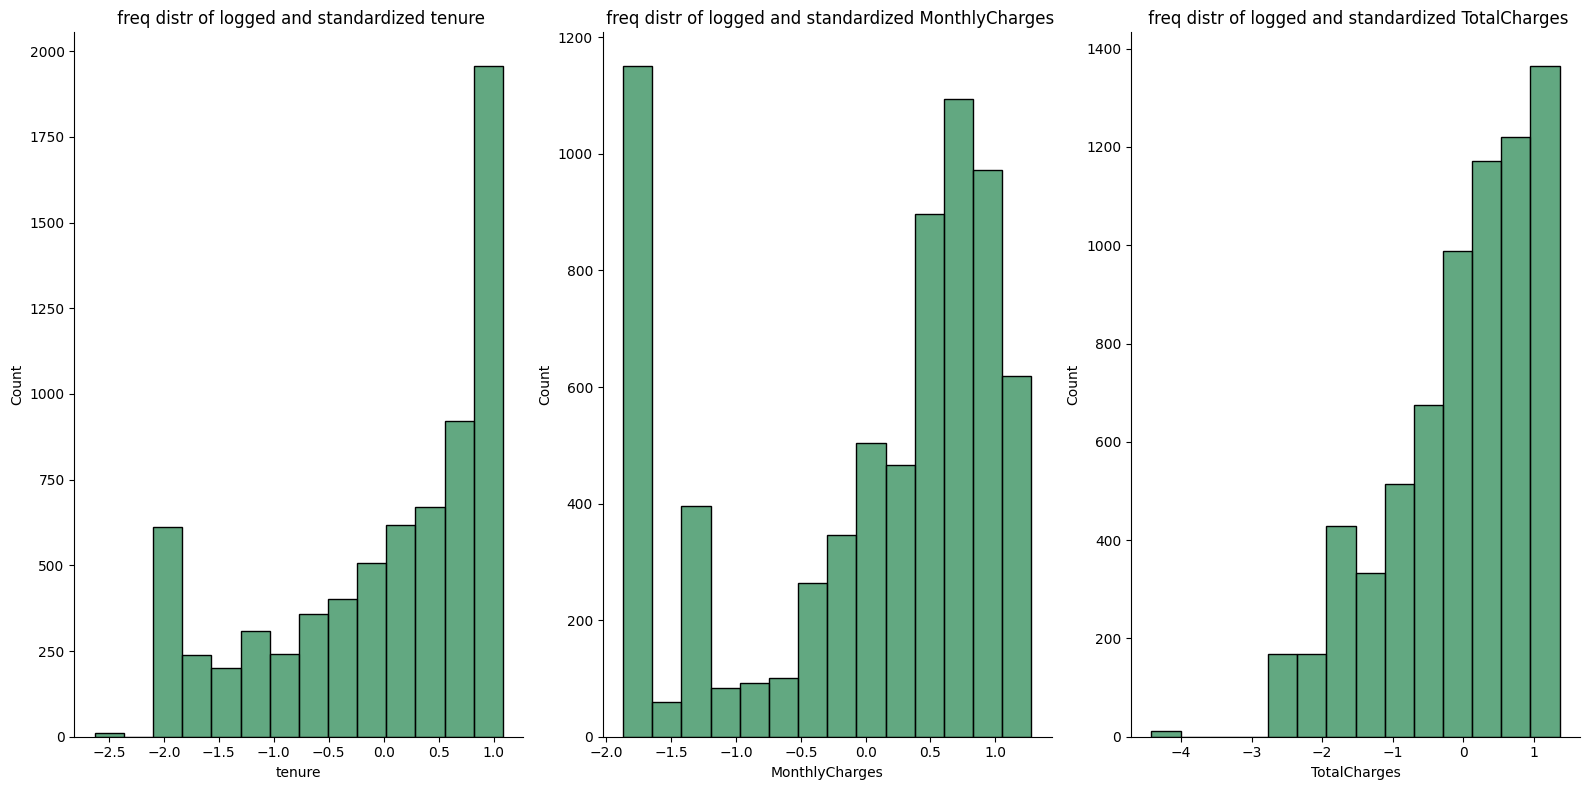

In [11]:
fig, axs = plt.subplots(1, 3, figsize =(16, 8))
for idx, column in enumerate(scaled_numeric_var.columns):
    sns.histplot(scaled_numeric_var[column], color = 'seagreen', ax=axs[idx], bins = 14)
    axs[idx].spines['top'].set_visible(False)
    axs[idx].spines['right'].set_visible(False)
    axs[idx].set_title(f" freq distr of logged and standardized {column}")
    plt.tight_layout()
plt.show() 

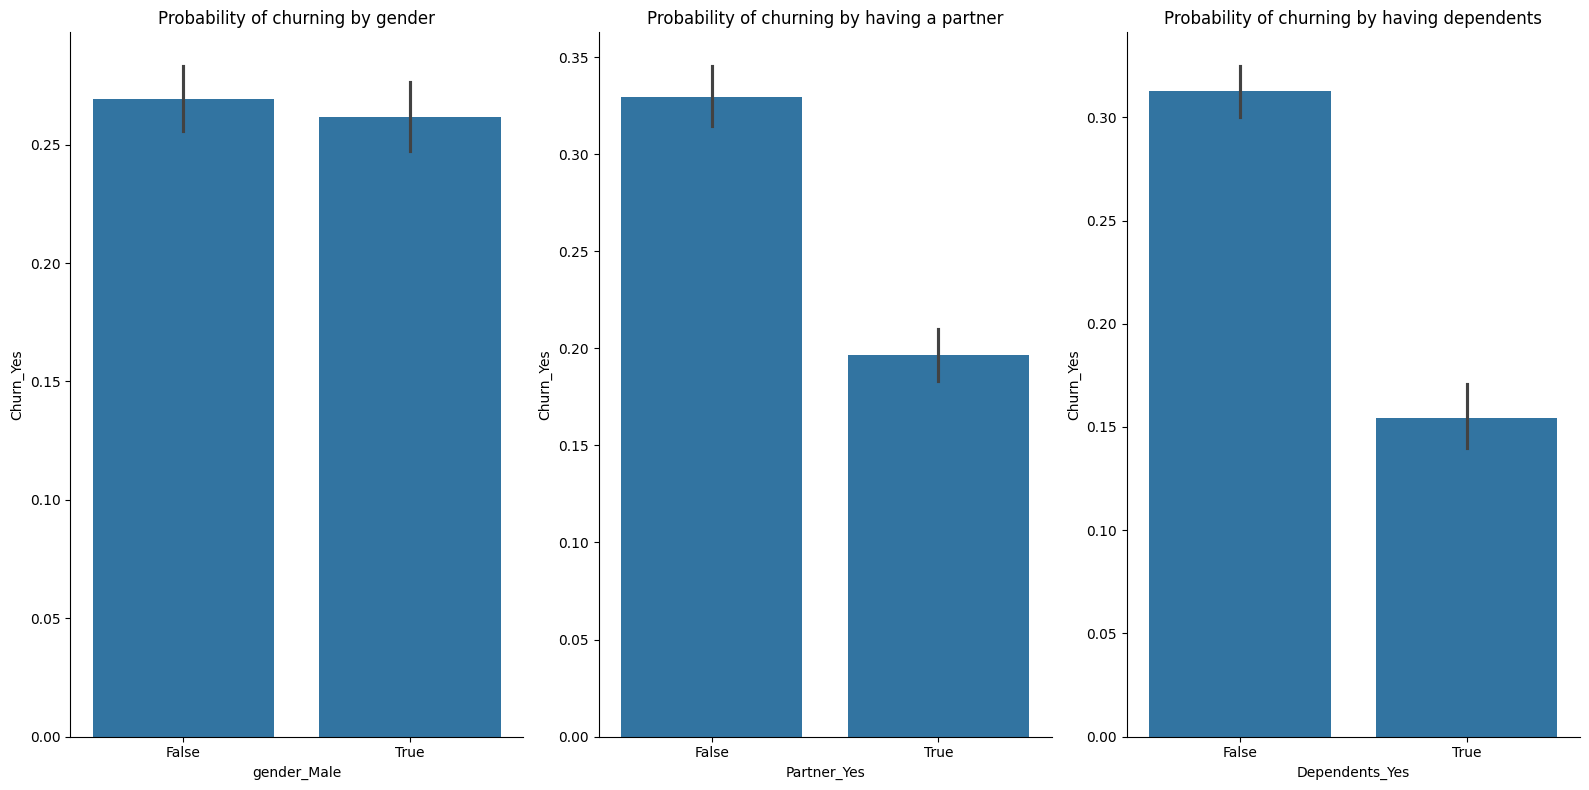

In [12]:
fig, axs = plt.subplots(1, 3, figsize =(16, 8))
sns.barplot(data = conv_df, x = 'gender_Male', y = 'Churn_Yes', ax = axs[0])
axs[0].spines['top'].set_visible(False)
axs[0].spines['right'].set_visible(False)
axs[0].set_title("Probability of churning by gender")

sns.barplot(data = conv_df, x = 'Partner_Yes', y = 'Churn_Yes', ax = axs[1])
axs[1].spines['top'].set_visible(False)
axs[1].spines['right'].set_visible(False)
axs[1].set_title("Probability of churning by having a partner")
    
sns.barplot(data = conv_df, x = 'Dependents_Yes', y = 'Churn_Yes', ax = axs[2])
axs[2].spines['top'].set_visible(False)
axs[2].spines['right'].set_visible(False)
axs[2].set_title("Probability of churning by having dependents")
plt.tight_layout()


In [13]:
conv_df['gender_Male'].value_counts() # 3555 men and 3488 similar amount
conv_df['Partner_Yes'].value_counts() # 3641 without partners and 3402 with
conv_df['Dependents_Yes'].value_counts() #4933 without dependents and only 2110 with

Dependents_Yes
False    4933
True     2110
Name: count, dtype: int64

In [14]:
conv_df.columns

Index(['customerID', 'SeniorCitizen', 'gender_Male', 'Partner_Yes',
       'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service',
       'MultipleLines_Yes', 'InternetService_Fiber optic',
       'InternetService_No', 'OnlineSecurity_No internet service',
       'OnlineSecurity_Yes', 'OnlineBackup_No internet service',
       'OnlineBackup_Yes', 'DeviceProtection_No internet service',
       'DeviceProtection_Yes', 'TechSupport_No internet service',
       'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'Churn_Yes', 'tenure', 'MonthlyCharges', 'TotalCharges'],
      dtype='object')

In [15]:
conv_df.groupby('Churn_Yes')['Contract_Two year'].value_counts() 
#We then proceed to look at the contract length as a possible factor towards churning

Churn_Yes  Contract_Two year
False      False                3527
           True                 1647
True       False                1821
           True                   48
Name: count, dtype: int64

In [16]:
one_month_contr = conv_df[(conv_df['Contract_One year'] == False) & (conv_df['Contract_Two year'] == False)]
one_month_contr.groupby('Churn_Yes').size()


Churn_Yes
False    2220
True     1655
dtype: int64

In [17]:
one_year_contr = conv_df[conv_df['Contract_One year'] == True]
two_years_contr = conv_df[conv_df['Contract_Two year'] == True]
one_month_contr.count() #3875 one-month contracts
one_year_contr.count() #1473 one-year contracts
two_years_contr.count() #1695 two-year-contracts


customerID                               1695
SeniorCitizen                            1695
gender_Male                              1695
Partner_Yes                              1695
Dependents_Yes                           1695
PhoneService_Yes                         1695
MultipleLines_No phone service           1695
MultipleLines_Yes                        1695
InternetService_Fiber optic              1695
InternetService_No                       1695
OnlineSecurity_No internet service       1695
OnlineSecurity_Yes                       1695
OnlineBackup_No internet service         1695
OnlineBackup_Yes                         1695
DeviceProtection_No internet service     1695
DeviceProtection_Yes                     1695
TechSupport_No internet service          1695
TechSupport_Yes                          1695
StreamingTV_No internet service          1695
StreamingTV_Yes                          1695
StreamingMovies_No internet service      1695
StreamingMovies_Yes               

In [ ]:
# The probability of churning having one_month_contract is extremely high compared to other contracts


In [ ]:
professional_blue = '#2874A6'
professional_green = '#28B463'
professional_gray = '#5D6D7E'
professional_red = '#C0392B'

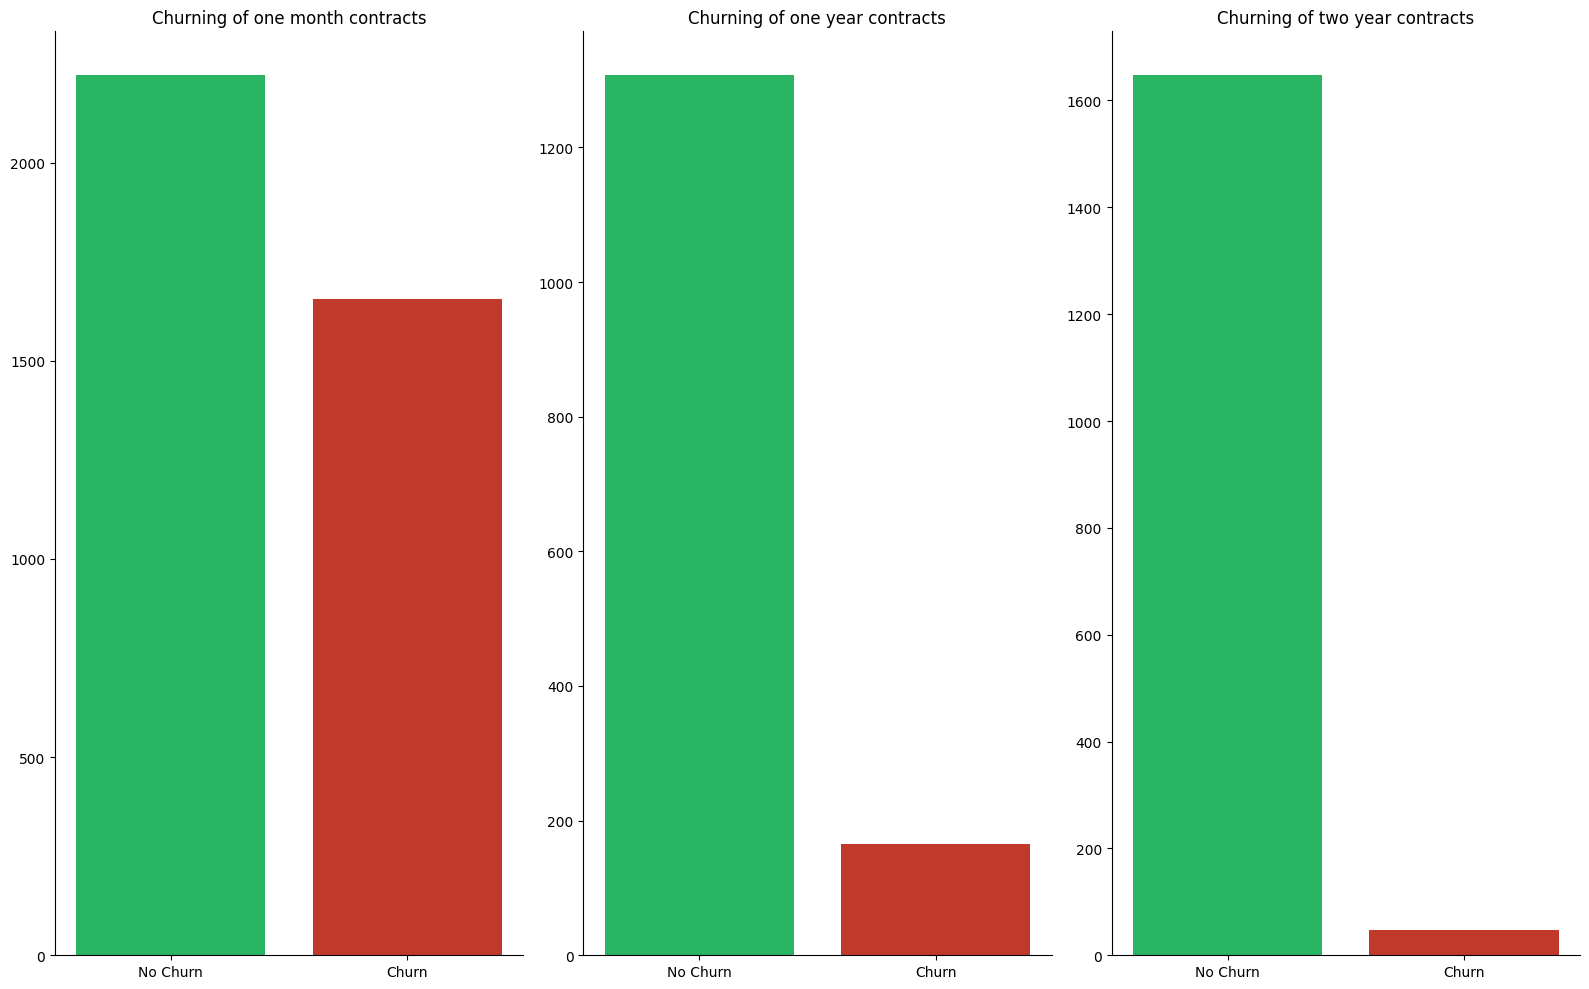

In [ ]:
churn_counts_month = one_month_contr.groupby('Churn_Yes').size()
churn_counts_year = one_year_contr.groupby('Churn_Yes').size()
churn_counts_two_year = two_years_contr.groupby('Churn_Yes').size()
fig, axs = plt.subplots(1, 3, figsize =(16, 10))

axs[0].bar(churn_counts_month.index, churn_counts_month.values, color=[professional_green, professional_red])

axs[0].set_xticks([0, 1])
axs[0].set_xticklabels(['No Churn', 'Churn'])
axs[0].set_title('Churning of one month contracts')
axs[0].spines['top'].set_visible(False)
axs[0].spines['right'].set_visible(False)
axs[1].bar(churn_counts_year.index, churn_counts_year.values, color=[professional_green, professional_red])

axs[1].set_xticks([0, 1])
axs[1].set_xticklabels(['No Churn', 'Churn'])
axs[1].set_title('Churning of one year contracts')
axs[1].spines['top'].set_visible(False)
axs[1].spines['right'].set_visible(False)

axs[2].bar(churn_counts_two_year.index, churn_counts_two_year.values, color=[professional_green, professional_red])

axs[2].set_xticks([0, 1])
axs[2].set_xticklabels(['No Churn', 'Churn'])
axs[2].set_title('Churning of two year contracts')
axs[2].spines['top'].set_visible(False)
axs[2].spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

In [ ]:
conv_df.columns
no_internet_users = conv_df[conv_df['InternetService_No'] == True]
int_users = conv_df[conv_df['InternetService_No'] == False]
internet_users = int_users.groupby('Churn_Yes').size()
non_int_users = no_internet_users.groupby('Churn_Yes').size()

In [ ]:
int_users.count() #5517 internet users
no_internet_users.count() #1526 non-internet users


customerID                               1526
SeniorCitizen                            1526
gender_Male                              1526
Partner_Yes                              1526
Dependents_Yes                           1526
PhoneService_Yes                         1526
MultipleLines_No phone service           1526
MultipleLines_Yes                        1526
InternetService_Fiber optic              1526
InternetService_No                       1526
OnlineSecurity_No internet service       1526
OnlineSecurity_Yes                       1526
OnlineBackup_No internet service         1526
OnlineBackup_Yes                         1526
DeviceProtection_No internet service     1526
DeviceProtection_Yes                     1526
TechSupport_No internet service          1526
TechSupport_Yes                          1526
StreamingTV_No internet service          1526
StreamingTV_Yes                          1526
StreamingMovies_No internet service      1526
StreamingMovies_Yes               

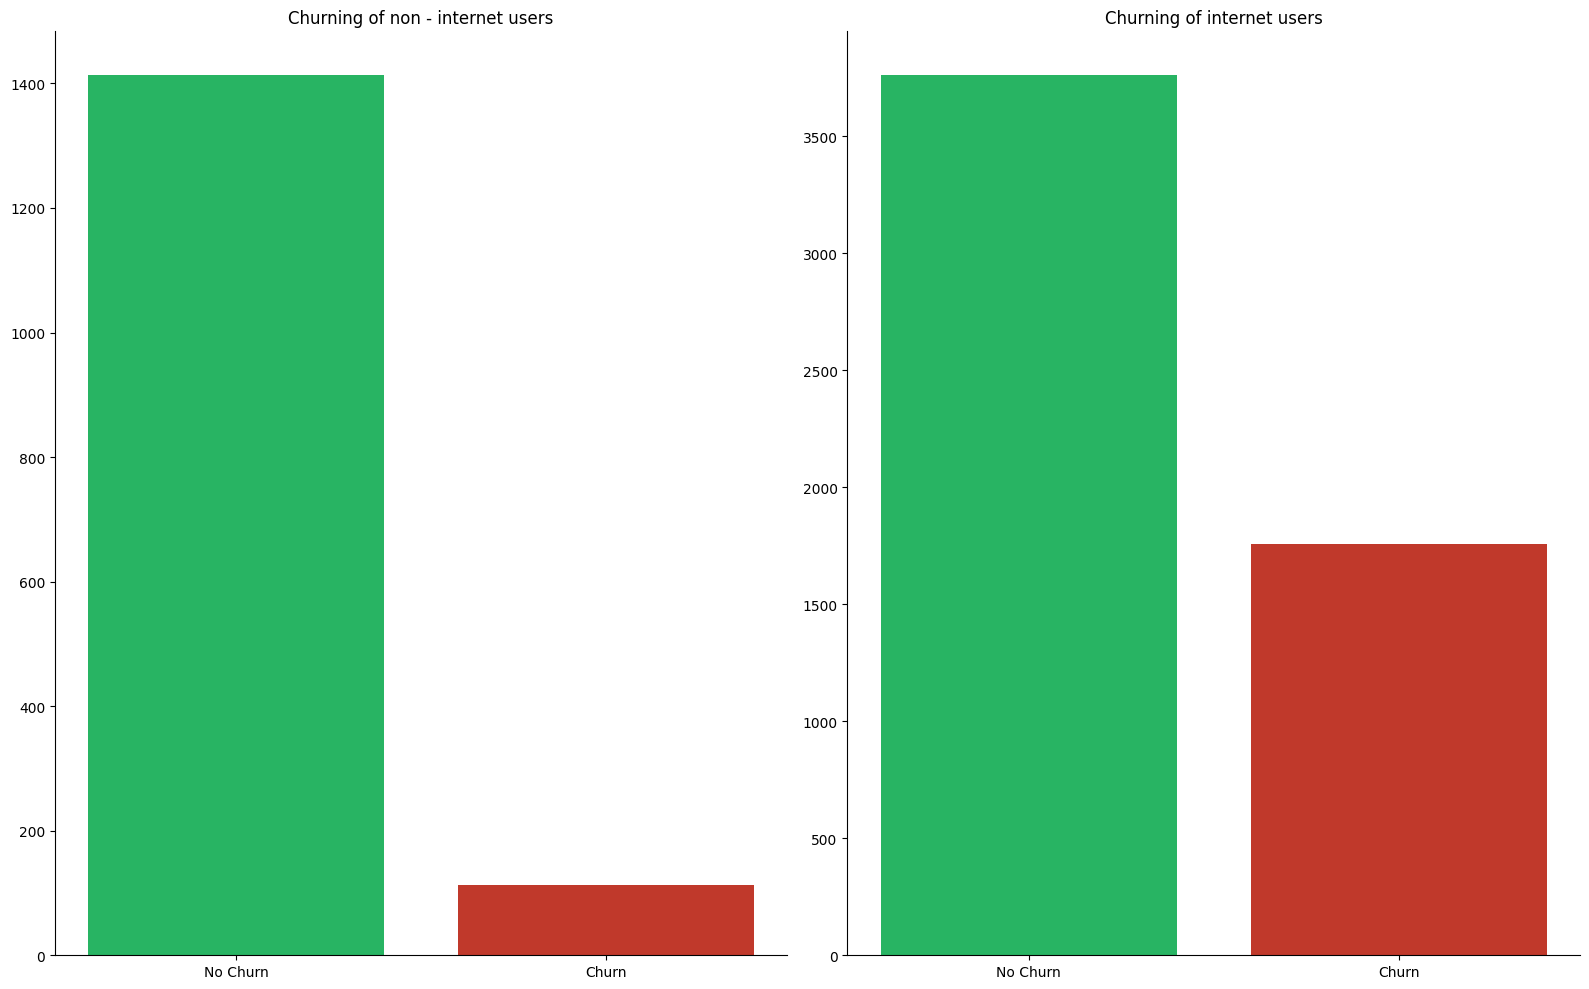

In [ ]:
fig, axs = plt.subplots(1, 2, figsize =(16, 10))

axs[0].bar(non_int_users.index, non_int_users.values, color = [professional_green, professional_red])
axs[0].set_xticks([0, 1])
axs[0].set_xticklabels(['No Churn', 'Churn'])
axs[0].set_title('Churning of non - internet users')
axs[0].spines['top'].set_visible(False)
axs[0].spines['right'].set_visible(False)

axs[1].bar(internet_users.index, internet_users.values, color=[professional_green, professional_red])
axs[1].set_xticks([0, 1])
axs[1].set_xticklabels(['No Churn', 'Churn'])
axs[1].set_title('Churning of internet users')
axs[1].spines['top'].set_visible(False)
axs[1].spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


In [ ]:
conv_df.columns

Index(['customerID', 'SeniorCitizen', 'gender_Male', 'Partner_Yes',
       'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service',
       'MultipleLines_Yes', 'InternetService_Fiber optic',
       'InternetService_No', 'OnlineSecurity_No internet service',
       'OnlineSecurity_Yes', 'OnlineBackup_No internet service',
       'OnlineBackup_Yes', 'DeviceProtection_No internet service',
       'DeviceProtection_Yes', 'TechSupport_No internet service',
       'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'Churn_Yes', 'tenure', 'MonthlyCharges', 'TotalCharges'],
      dtype='object')

In [ ]:
paperless_users = conv_df[conv_df['PaperlessBilling_Yes'] == True]
non_paperless_users = conv_df[conv_df['PaperlessBilling_Yes'] == False]
paper_churn = paperless_users.groupby('Churn_Yes').size()
non_paper_churn = non_paperless_users.groupby('Churn_Yes').size()

In [ ]:
paperless_users.count() #4171 paperless users
non_paperless_users.count() # 2872 non-paperless users 

customerID                               2872
SeniorCitizen                            2872
gender_Male                              2872
Partner_Yes                              2872
Dependents_Yes                           2872
PhoneService_Yes                         2872
MultipleLines_No phone service           2872
MultipleLines_Yes                        2872
InternetService_Fiber optic              2872
InternetService_No                       2872
OnlineSecurity_No internet service       2872
OnlineSecurity_Yes                       2872
OnlineBackup_No internet service         2872
OnlineBackup_Yes                         2872
DeviceProtection_No internet service     2872
DeviceProtection_Yes                     2872
TechSupport_No internet service          2872
TechSupport_Yes                          2872
StreamingTV_No internet service          2872
StreamingTV_Yes                          2872
StreamingMovies_No internet service      2872
StreamingMovies_Yes               

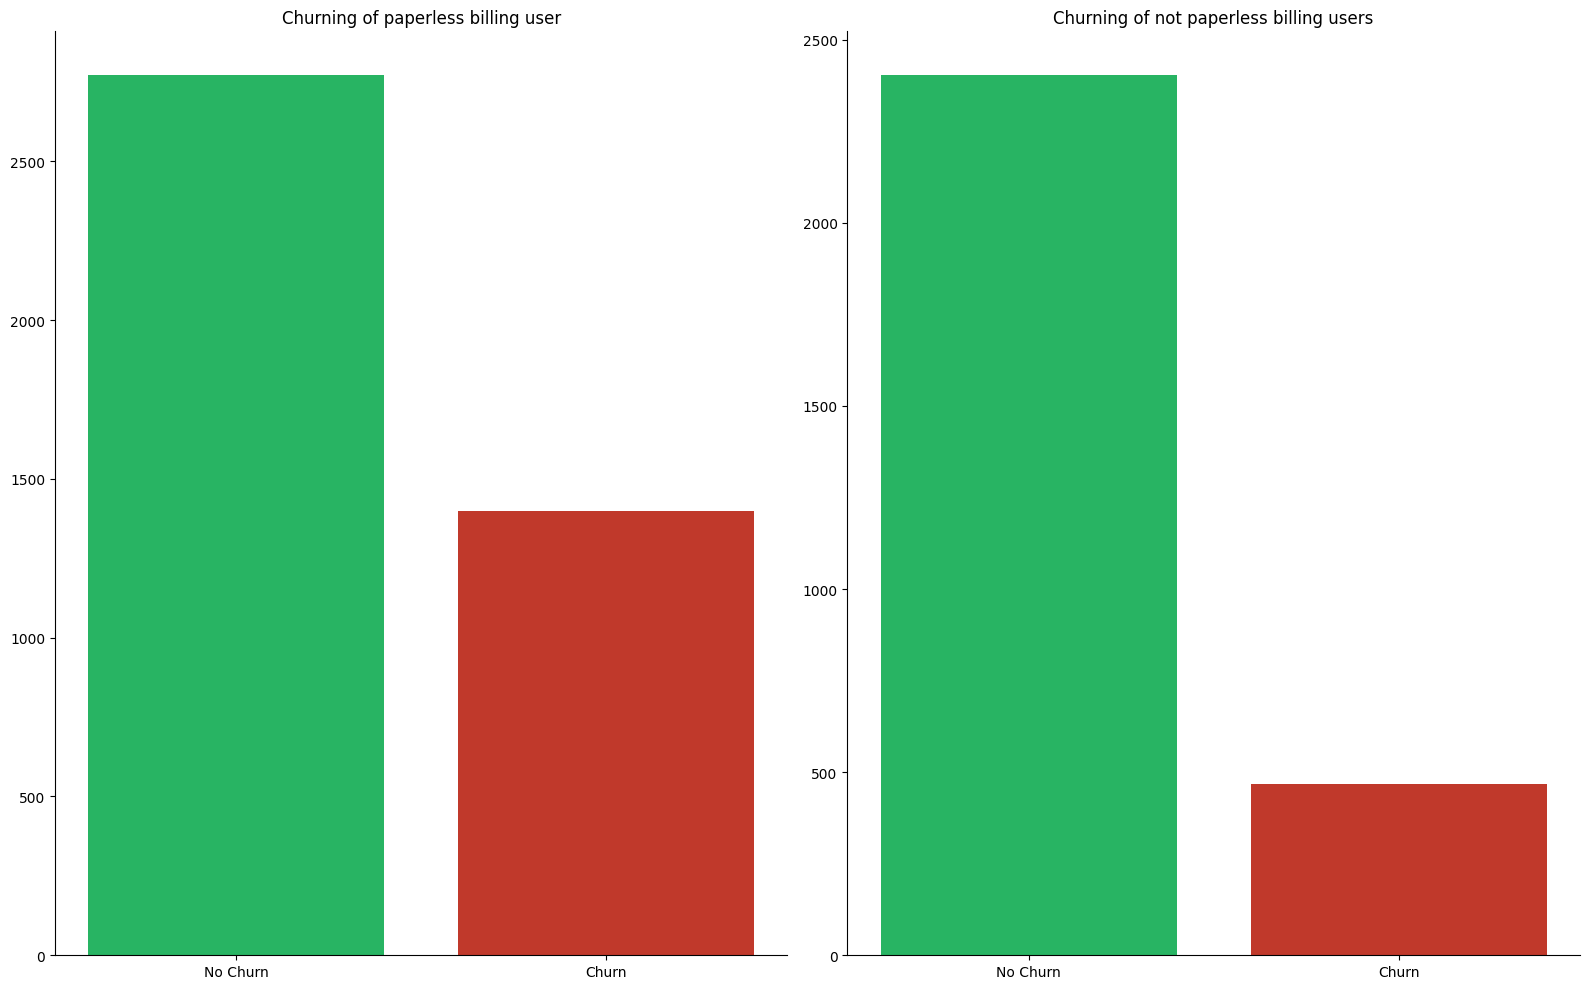

In [ ]:
fig, axs = plt.subplots(1, 2, figsize =(16, 10))

axs[0].bar(paper_churn.index, paper_churn.values, color = [professional_green, professional_red])
axs[0].set_xticks([0, 1])
axs[0].set_xticklabels(['No Churn', 'Churn'])
axs[0].set_title('Churning of paperless billing user')
axs[0].spines['top'].set_visible(False)
axs[0].spines['right'].set_visible(False)

axs[1].bar(non_paper_churn.index, non_paper_churn.values, color=[professional_green, professional_red])
axs[1].set_xticks([0, 1])
axs[1].set_xticklabels(['No Churn', 'Churn'])
axs[1].set_title('Churning of not paperless billing users')
axs[1].spines['top'].set_visible(False)
axs[1].spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

In [ ]:
conv_df.groupby('Churn_Yes')['tenure'].mean()

Churn_Yes
False    37.569965
True     17.979133
Name: tenure, dtype: float64

In [ ]:
conv_df.groupby('Churn_Yes')['MonthlyCharges'].mean()

Churn_Yes
False    61.265124
True     74.441332
Name: MonthlyCharges, dtype: float64

In [ ]:
conv_df['TotalCharges'] = pd.to_numeric(conv_df['TotalCharges'], errors='coerce')
conv_df.groupby('Churn_Yes')['TotalCharges'].mean()

Churn_Yes
False    2555.344141
True     1531.796094
Name: TotalCharges, dtype: float64

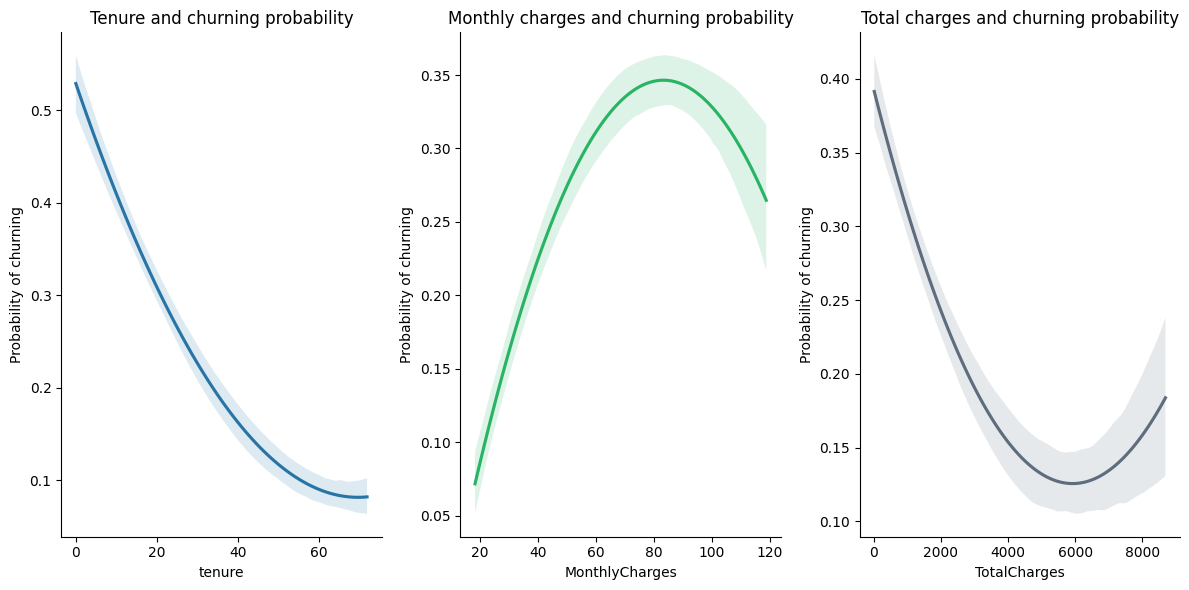

In [ ]:
fig, axs = plt.subplots(1, 3, figsize =(12, 6))
sns.regplot(x = 'tenure', y = 'Churn_Yes', data = conv_df, 
            ax = axs[0], order =2, ci = 99, color = professional_blue, scatter=False)
axs[0].set_title('Tenure and churning probability')
axs[0].spines['top'].set_visible(False)
axs[0].spines['right'].set_visible(False)
axs[0].set_ylabel("Probability of churning")

sns.regplot(x = 'MonthlyCharges', y = 'Churn_Yes', data = conv_df, 
            ax = axs[1], order =2, ci = 99, color = professional_green, scatter=False)
axs[1].set_title('Monthly charges and churning probability')
axs[1].spines['top'].set_visible(False)
axs[1].spines['right'].set_visible(False)
axs[1].set_ylabel("Probability of churning")

sns.regplot(x = 'TotalCharges', y = 'Churn_Yes', data = conv_df, 
            ax = axs[2], order =2, ci = 99, color = '#5D6D7E', scatter=False)
axs[2].set_title('Total charges and churning probability')
axs[2].spines['top'].set_visible(False)
axs[2].spines['right'].set_visible(False)
axs[2].set_ylabel("Probability of churning")
plt.tight_layout()


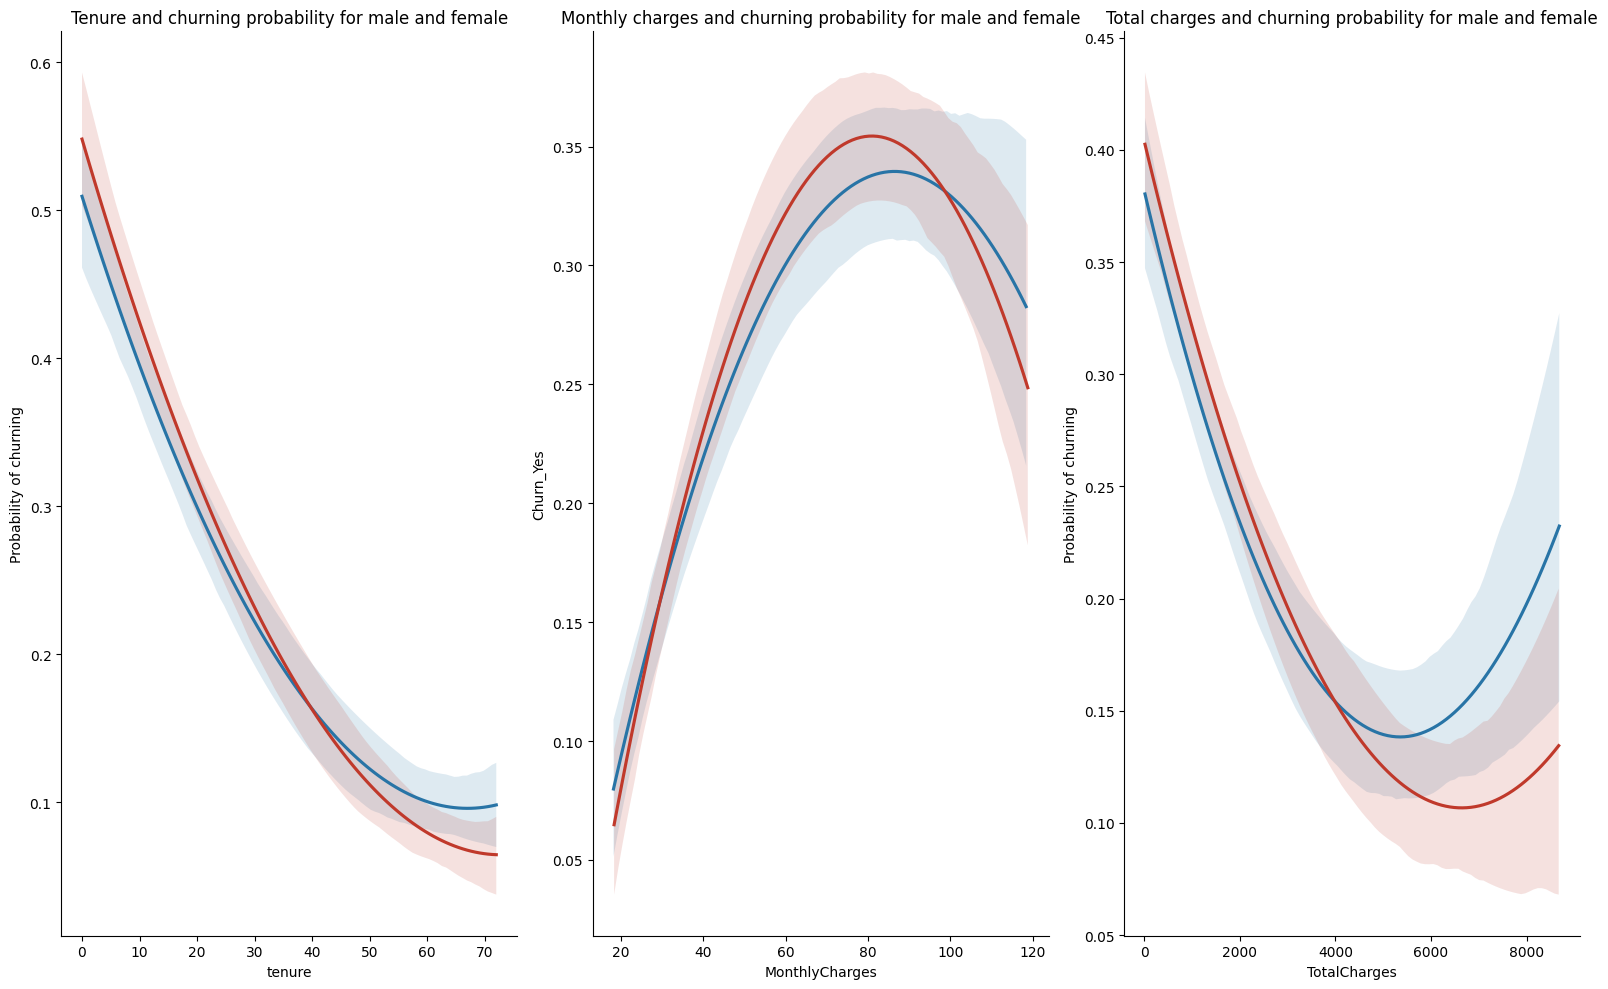

In [ ]:
fig, axs = plt.subplots(1, 3, figsize =(16, 10))
sns.regplot(x = 'tenure', y = 'Churn_Yes', data = conv_df[conv_df[
    'gender_Male'] == True], 
            ax = axs[0], order =2, ci = 99, color = professional_blue, scatter=False)
sns.regplot(x = 'tenure', y = 'Churn_Yes', data = conv_df[conv_df[
    'gender_Male'] == False], 
            ax = axs[0], order =2, ci = 99, color = professional_red, scatter=False)
axs[0].set_title('Tenure and churning probability for male and female')
axs[0].spines['top'].set_visible(False)
axs[0].spines['right'].set_visible(False)
axs[0].set_ylabel("Probability of churning")

sns.regplot(x = 'MonthlyCharges', y = 'Churn_Yes', data = conv_df[conv_df[
    'gender_Male'] == True], 
            ax = axs[1], order =2, ci = 99, color = professional_blue, scatter=False)
axs[1].set_title('Monthly charges and churning probability for male and female')
axs[1].spines['top'].set_visible(False)
axs[1].spines['right'].set_visible(False)
axs[1].set_ylabel("Probability of churning")
sns.regplot(x = 'MonthlyCharges', y = 'Churn_Yes', data = conv_df[conv_df[
    'gender_Male'] == False], 
            ax = axs[1], order =2, ci = 99, color = professional_red, scatter=False)

sns.regplot(x = 'TotalCharges', y = 'Churn_Yes', data = conv_df[conv_df[
    'gender_Male'] == True], 
            ax = axs[2], order =2, ci = 99, color = professional_blue, scatter=False)
sns.regplot(x = 'TotalCharges', y = 'Churn_Yes', data = conv_df[conv_df[
    'gender_Male'] == False], 
            ax = axs[2], order =2, ci = 99, color = professional_red, scatter=False)
axs[2].set_title('Total charges and churning probability for male and female')
axs[2].spines['top'].set_visible(False)
axs[2].spines['right'].set_visible(False)
axs[2].set_ylabel("Probability of churning")
plt.tight_layout()


In [ ]:
conv_df['Churn_Yes'].value_counts()

Churn_Yes
False    5174
True     1869
Name: count, dtype: int64

In [ ]:
X = conv_df.drop(['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_Yes'], axis=1, errors='ignore')
X = pd.concat([X, scaled_numeric_var], axis=1)
y = conv_df[['Churn_Yes']]
y = np.ravel(y)
X['TotalCharges'] = X['TotalCharges'].fillna(0)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
X_train = np.ascontiguousarray(X_train)
X_test = np.ascontiguousarray(X_test)

In [ ]:
def benchmark(clf: BaseEstimator, custom_name: str = "") -> dict:
    model = clf
    clf_descr = custom_name if custom_name else clf.__class__.__name__

    logging.info(f"{'-'*80}\nTraining: {clf_descr}")

    try:
        t0 = time.time()
        model.fit(X_train, y_train)
        train_time = time.time() - t0

        t0 = time.time()
        pred_test = model.predict(X_test)
        test_time = time.time() - t0
        
        t0 = time.time()
        pred_train = model.predict(X_train)
        train_pred_time = time.time() - t0

        score_test = accuracy_score(y_test, pred_test)
        f1_test = f1_score(y_test, pred_test, average='binary')
        recall_test = recall_score(y_test, pred_test, average='binary')
        precision_test = precision_score(y_test, pred_test, average='binary')
        roc_auc_test = roc_auc_score(y_test, pred_test)
        
        score_train = accuracy_score(y_train, pred_train)
        f1_train = f1_score(y_train, pred_train, average='binary')
        recall_train = recall_score(y_train, pred_train, average='binary')
        precision_train = precision_score(y_train, pred_train, average='binary')
        roc_auc_train = roc_auc_score(y_train, pred_train)
        
        # Plotting confusion matrix
        def plot_confusion_matrix(y_true, y_pred, title):
            matrix = confusion_matrix(y_true, y_pred)
            plt.figure(figsize=(5, 5))
            sns.heatmap(matrix, annot=True, fmt='d', cmap='Greens', cbar=False)
            plt.xlabel('Predicted Label')
            plt.ylabel('True Label')
            plt.title(title)
            plt.show()

        plot_confusion_matrix(y_test, pred_test, f"Confusion Matrix (Test) - {clf_descr}")

        logging.info(f"Test Metrics:")
        logging.info(f"Train time: {train_time:.3f}s")
        logging.info(f"Test time:  {test_time:.3f}s")
        logging.info(f"Accuracy:   {score_test:.3f}")
        logging.info(f"F1 Score:   {f1_test:.3f}")
        logging.info(f"Recall:     {recall_test:.3f}")
        logging.info(f"Precision:  {precision_test:.3f}")
        logging.info(f"ROC AUC:    {roc_auc_test:.3f}\n")

        logging.info(f"Training Metrics (on training set):")
        logging.info(f"Prediction time: {train_pred_time:.3f}s")
        logging.info(f"Accuracy:   {score_train:.3f}")
        logging.info(f"F1 Score:   {f1_train:.3f}")
        logging.info(f"Recall:     {recall_train:.3f}")
        logging.info(f"Precision:  {precision_train:.3f}")
        logging.info(f"ROC AUC:    {roc_auc_train:.3f}\n")

    except Exception as e:
        logging.error(f"Error training {clf_descr}: {e}")
        return {
            'Classifier': clf_descr,
            'Error': str(e)
        }

    return {
        'Classifier': clf_descr,
        'Test Accuracy': score_test,
        'Test F1 Score': f1_test,
        'Test Recall': recall_test,
        'Test Precision': precision_test,
        'Test ROC AUC': roc_auc_test,
        'Train Time': train_time,
        'Test Time': test_time,
        'Train Accuracy': score_train,
        'Train F1 Score': f1_train,
        'Train Recall': recall_train,
        'Train Precision': precision_train,
        'Train ROC AUC': roc_auc_train,
        'Train Prediction Time': train_pred_time
    }

In [ ]:
logit = LogisticRegression(max_iter = 10000, solver = 'saga')
knn = KNeighborsClassifier()
pol_logit = Pipeline([
    ('poly_features', PolynomialFeatures(degree=3)),
    ('logistic_regression', LogisticRegression(max_iter=10000))
])

R_forest = RandomForestClassifier()
bagging = XGBClassifier()
param_logit = { 'C': [0.001, 0.1, 1, 100],
              'penalty': ['l1', 'l2', 'none']}

param_knn = {'n_neighbors': [3, 5, 7, 9, 11, 13, 15, 17, 19],
            'weights': ['uniform', 'distance'],}

param_forest ={ 'max_depth' : [3, 5, 7, 9], 
             'n_estimators' : [100, 200], 
            'max_features': ['sqrt', 'log2'],
            'class_weight' :[{0:1, 1:20}, 'balanced']}
param_bagging = {
    'n_estimators': [100, 200, 300], 
    'learning_rate': [0.01, 0.1, 0.2],  
    'max_depth': [3, 6, 9],  
    'min_child_weight': [1, 3, 5], 
}
 
gridsearch_logit = GridSearchCV(logit, param_logit, scoring = 'f1', n_jobs = -1)
gridsearch_r_forest = GridSearchCV(R_forest, param_forest, scoring = 'f1', n_jobs = -1)
gridsearch_knn = GridSearchCV(knn, param_knn, scoring = 'f1', n_jobs = -1 )
gridsearch_bagging = GridSearchCV(bagging, param_bagging, scoring = 'f1', n_jobs = 1)

c:\Python311\Lib\site-packages\sklearn\model_selection\_validation.py:547: FitFailedWarning: 
20 fits failed out of a total of 60.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
6 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Python311\Lib\site-packages\sklearn\model_selection\_validation.py", line 895, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Python311\Lib\site-packages\sklearn\base.py", line 1467, in wrapper
    estimator._validate_params()
  File "c:\Python311\Lib\site-packages\sklearn\base.py", line 666, in _validate_params
    validate_parameter_constraints(
  File "c:\Python311\Lib\site-packages\sklearn\utils\_param_validation.py", line 95, in validate_par

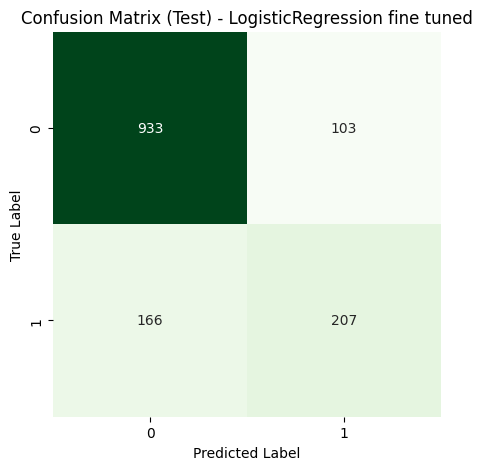

{'Classifier': 'LogisticRegression fine tuned',
 'Test Accuracy': 0.8090844570617459,
 'Test F1 Score': 0.6061493411420205,
 'Test Recall': 0.5549597855227882,
 'Test Precision': 0.667741935483871,
 'Test ROC AUC': 0.7277694680509694,
 'Train Time': 28.78064799308777,
 'Test Time': 0.005709171295166016,
 'Train Accuracy': 0.8079517216897408,
 'Train F1 Score': 0.5935386927122465,
 'Train Recall': 0.5280748663101604,
 'Train Precision': 0.6775300171526587,
 'Train ROC AUC': 0.7186048570313489,
 'Train Prediction Time': 0.007538795471191406}

In [ ]:
benchmark(gridsearch_logit, "LogisticRegression fine tuned")

In [ ]:
results_logit = pd.DataFrame(gridsearch_logit.cv_results_)
best_logit_params = gridsearch_logit.best_params_
best_logit_params

{'C': 100, 'penalty': 'l1'}

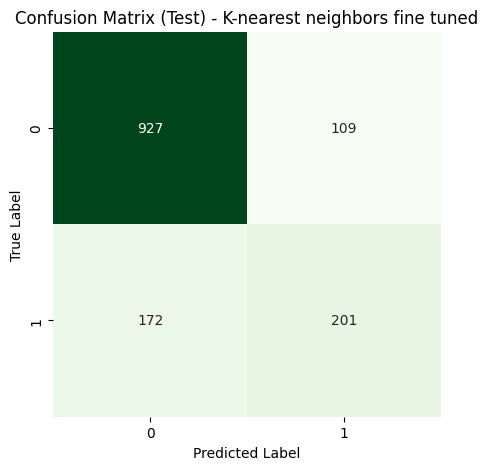

{'Classifier': 'K-nearest neighbors fine tuned',
 'Test Accuracy': 0.8005677785663591,
 'Test F1 Score': 0.5885797950219619,
 'Test Recall': 0.5388739946380697,
 'Test Precision': 0.6483870967741936,
 'Test ROC AUC': 0.7168308197128573,
 'Train Time': 2.1101253032684326,
 'Test Time': 0.5045647621154785,
 'Train Accuracy': 0.8122115725949591,
 'Train F1 Score': 0.6199712643678161,
 'Train Recall': 0.5768716577540107,
 'Train Precision': 0.6700310559006211,
 'Train ROC AUC': 0.7370825180988516,
 'Train Prediction Time': 0.48001527786254883}

In [ ]:
benchmark(gridsearch_knn, "K-nearest neighbors fine tuned")

In [ ]:
results_knn = pd.DataFrame(gridsearch_knn.cv_results_)
best_knn_params = gridsearch_knn.best_params_
best_knn_params

{'n_neighbors': 17, 'weights': 'uniform'}

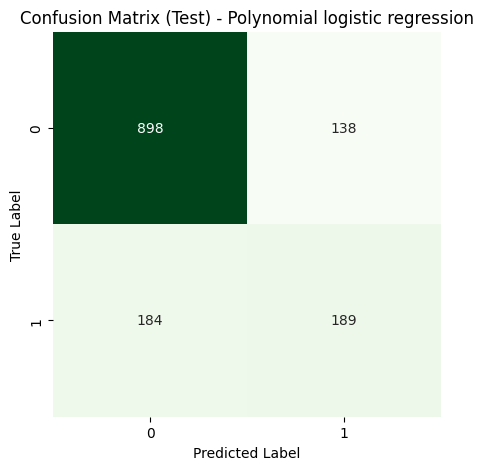

{'Classifier': 'Polynomial logistic regression',
 'Test Accuracy': 0.7714691270404542,
 'Test F1 Score': 0.54,
 'Test Recall': 0.5067024128686327,
 'Test Precision': 0.5779816513761468,
 'Test ROC AUC': 0.6867488898319998,
 'Train Time': 25.30200481414795,
 'Test Time': 0.17774534225463867,
 'Train Accuracy': 0.8627973020944267,
 'Train F1 Score': 0.724813100747597,
 'Train Recall': 0.68048128342246,
 'Train Precision': 0.7753236862147753,
 'Train ROC AUC': 0.8045954024652174,
 'Train Prediction Time': 0.41069889068603516}

In [ ]:
benchmark(pol_logit, 'Polynomial logistic regression' )

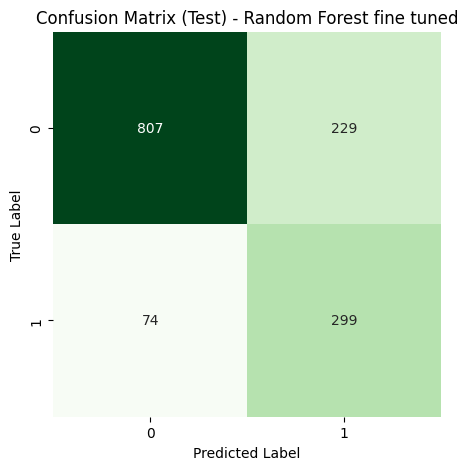

{'Classifier': 'Random Forest fine tuned',
 'Test Accuracy': 0.7849538679914834,
 'Test F1 Score': 0.6637069922308546,
 'Test Recall': 0.8016085790884718,
 'Test Precision': 0.5662878787878788,
 'Test ROC AUC': 0.7902830540230005,
 'Train Time': 21.131654977798462,
 'Test Time': 0.03644752502441406,
 'Train Accuracy': 0.8248136315228967,
 'Train F1 Score': 0.7251461988304093,
 'Train Recall': 0.8703208556149733,
 'Train Precision': 0.6214797136038186,
 'Train ROC AUC': 0.8393411914614256,
 'Train Prediction Time': 0.09115052223205566}

In [ ]:
benchmark(gridsearch_r_forest, "Random Forest fine tuned")

In [ ]:
results_r_forest = pd.DataFrame(gridsearch_r_forest.cv_results_)
best_r_forest_params = gridsearch_r_forest.best_params_
best_r_forest_model = gridsearch_r_forest.best_estimator_
best_r_forest_params

{'class_weight': 'balanced',
 'max_depth': 9,
 'max_features': 'sqrt',
 'n_estimators': 100}

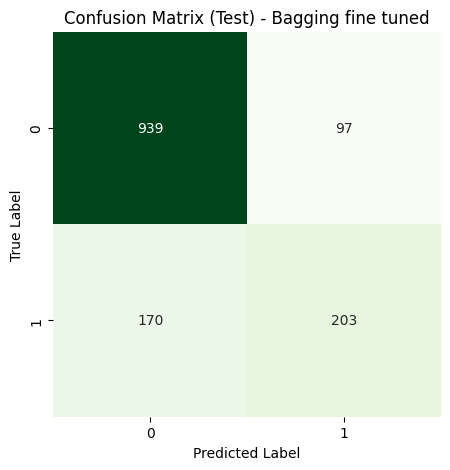

{'Classifier': 'Bagging fine tuned',
 'Test Accuracy': 0.8105039034776437,
 'Test F1 Score': 0.6032689450222882,
 'Test Recall': 0.5442359249329759,
 'Test Precision': 0.6766666666666666,
 'Test ROC AUC': 0.7253032906518162,
 'Train Time': 114.33528232574463,
 'Test Time': 0.007966756820678711,
 'Train Accuracy': 0.8198438054668087,
 'Train F1 Score': 0.6159667045024593,
 'Train Recall': 0.5441176470588235,
 'Train Precision': 0.7096774193548387,
 'Train ROC AUC': 0.7318219941432348,
 'Train Prediction Time': 0.014074087142944336}

In [ ]:
benchmark(gridsearch_bagging , "Bagging fine tuned")

In [ ]:
results_bagging = pd.DataFrame(gridsearch_bagging.cv_results_)
best_bagging_params = gridsearch_bagging.best_params_
best_bagging_params

{'learning_rate': 0.1,
 'max_depth': 3,
 'min_child_weight': 5,
 'n_estimators': 100}

c:\Python311\Lib\site-packages\sklearn\model_selection\_validation.py:547: FitFailedWarning: 
20 fits failed out of a total of 60.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
4 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Python311\Lib\site-packages\sklearn\model_selection\_validation.py", line 895, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Python311\Lib\site-packages\sklearn\base.py", line 1467, in wrapper
    estimator._validate_params()
  File "c:\Python311\Lib\site-packages\sklearn\base.py", line 666, in _validate_params
    validate_parameter_constraints(
  File "c:\Python311\Lib\site-packages\sklearn\utils\_param_validation.py", line 95, in validate_par

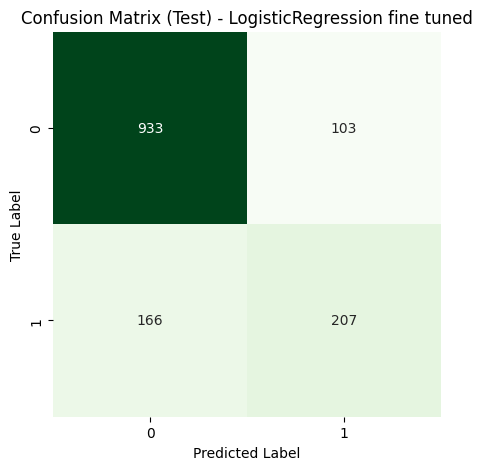

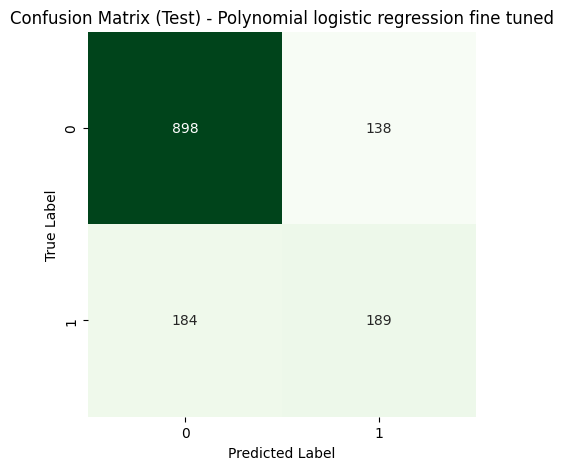

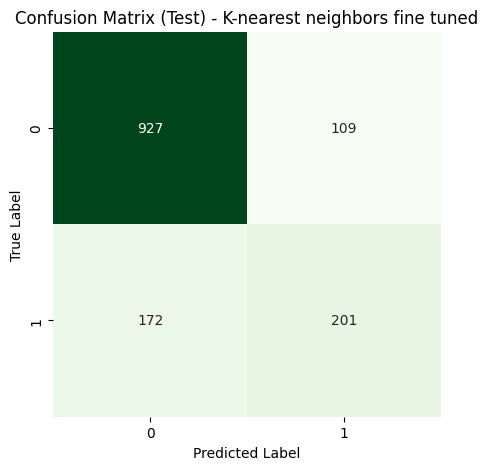

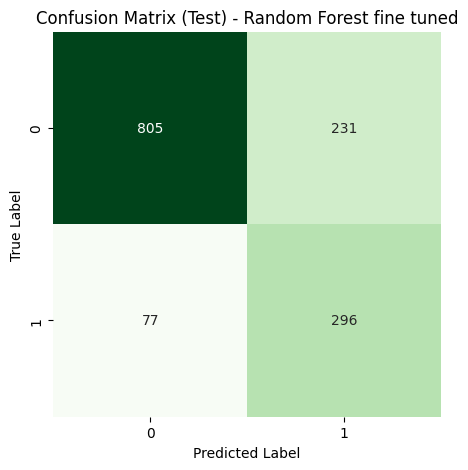

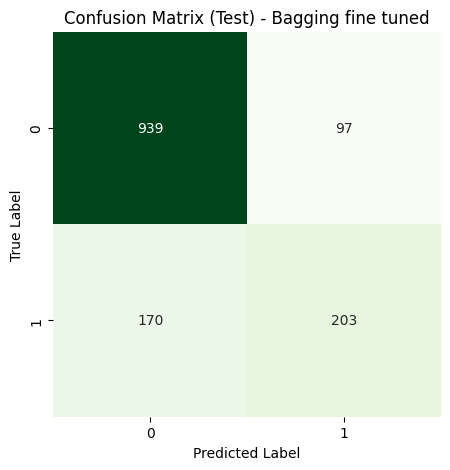

In [ ]:
classifiers = [
    (gridsearch_logit, "LogisticRegression fine tuned"),
    (pol_logit, "Polynomial logistic regression fine tuned"),
    (gridsearch_knn, "K-nearest neighbors fine tuned"),
    (gridsearch_r_forest, "Random Forest fine tuned"),
    (gridsearch_bagging , "Bagging fine tuned"),
]
for clf, name in classifiers:
    benchmark(clf, name)

In [ ]:
feature_importances = best_r_forest_model.feature_importances_
sorted_indices = np.argsort(feature_importances)
top_10_indices = sorted_indices[-10:]

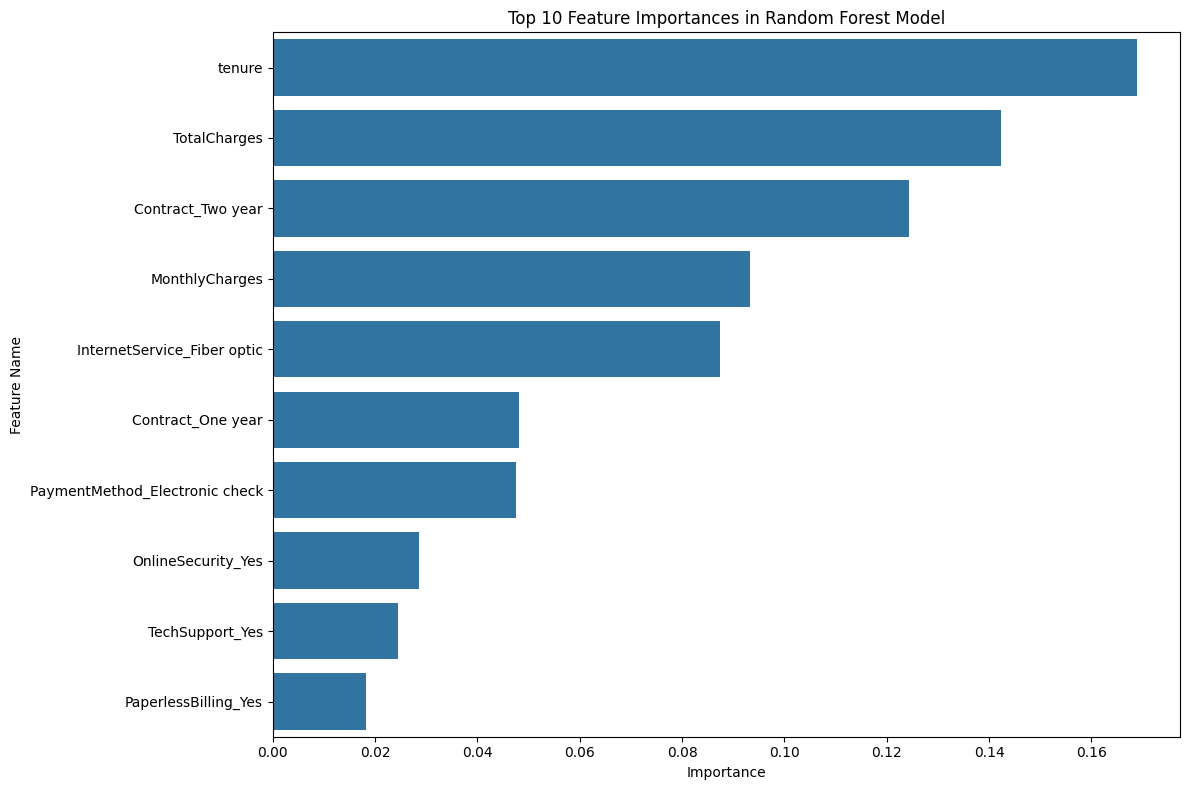

In [ ]:
feature_names = []
for name in X.columns:
    feature_names.append(name)
top_10_feature_names = [feature_names[i] for i in top_10_indices]
top_10_features_df = pd.DataFrame({
    'Feature Name': top_10_feature_names,
    'Importance': feature_importances[top_10_indices]
}).sort_values(by='Importance', ascending=False)
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature Name', data=top_10_features_df, orient='h')
plt.title('Top 10 Feature Importances in Random Forest Model')
plt.xlabel('Importance')
plt.ylabel('Feature Name')
plt.tight_layout()

In [ ]:
# Bonus nr. 1, implementing SMOTE

                                              0.0/257.7 kB ? eta -:--:--
     ----------------------------           194.6/257.7 kB 5.8 MB/s eta 0:00:01
     -------------------------------------- 257.7/257.7 kB 5.3 MB/s eta 0:00:00



[notice] A new release of pip is available: 23.1.2 -> 24.0
[notice] To update, run: python.exe -m pip install --upgrade pip


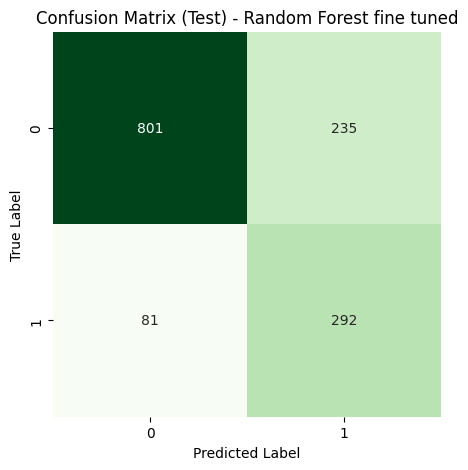

{'Classifier': 'Random Forest fine tuned',
 'Test Accuracy': 0.7757274662881476,
 'Test F1 Score': 0.6488888888888888,
 'Test Recall': 0.7828418230563002,
 'Test Precision': 0.5540796963946869,
 'Test ROC AUC': 0.7780039231111617,
 'Train Time': 43.22433543205261,
 'Test Time': 0.06371784210205078,
 'Train Accuracy': 0.8507733204446593,
 'Train F1 Score': 0.8575054805584401,
 'Train Recall': 0.8980183663605606,
 'Train Precision': 0.8204901744314418,
 'Train ROC AUC': 0.8507733204446593,
 'Train Prediction Time': 0.26945924758911133}

In [ ]:
!pip install imblearn
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

smote = SMOTE()
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

X_train, y_train = X_train_smote, y_train_smote

benchmark(gridsearch_r_forest, "Random Forest fine tuned")



In [ ]:
results_r_forest = pd.DataFrame(gridsearch_r_forest.cv_results_)
best_r_forest_params = gridsearch_r_forest.best_params_
best_r_forest_model = gridsearch_r_forest.best_estimator_
best_r_forest_params
feature_importances = best_r_forest_model.feature_importances_
sorted_indices = np.argsort(feature_importances)
top_10_indices = sorted_indices[-10:]

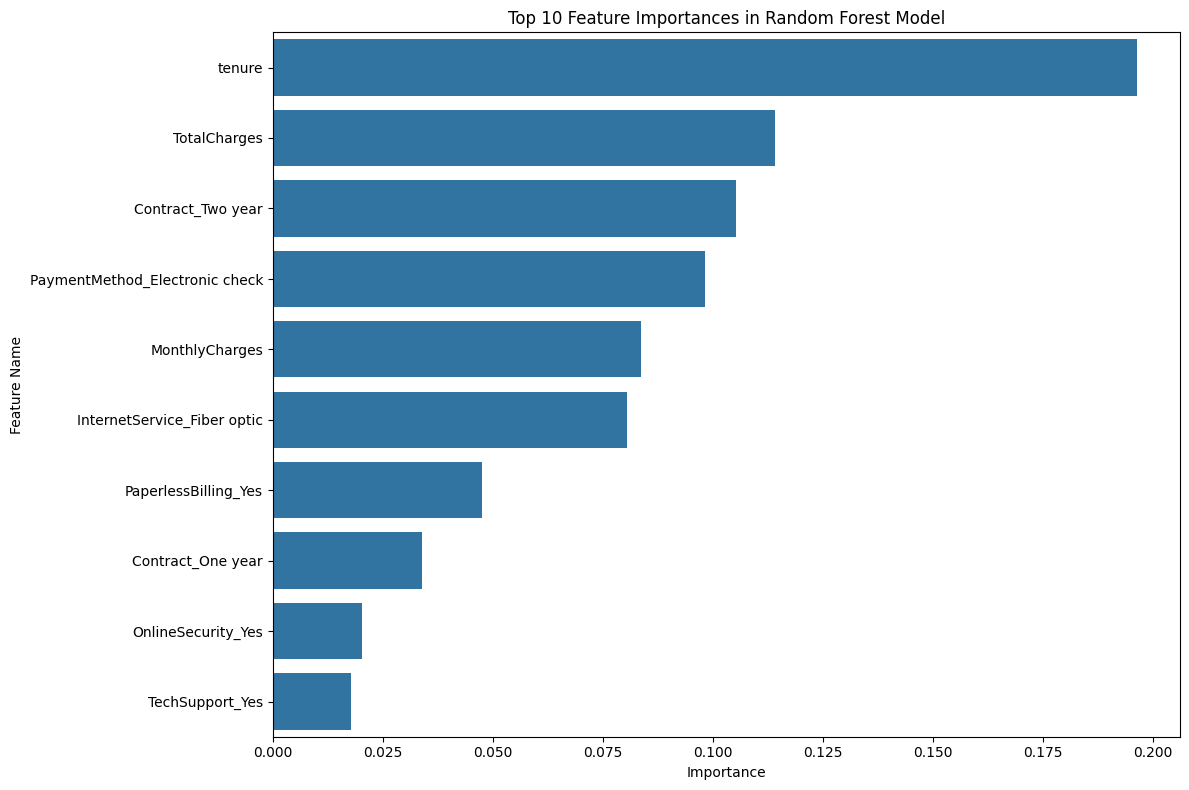

In [ ]:
feature_names = []
for name in X.columns:
    feature_names.append(name)
top_10_feature_names = [feature_names[i] for i in top_10_indices]
top_10_features_df = pd.DataFrame({
    'Feature Name': top_10_feature_names,
    'Importance': feature_importances[top_10_indices]
}).sort_values(by='Importance', ascending=False)
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature Name', data=top_10_features_df, orient='h')
plt.title('Top 10 Feature Importances in Random Forest Model')
plt.xlabel('Importance')
plt.ylabel('Feature Name')
plt.tight_layout()

In [ ]:
#Bonus nr.2, estimating aditional revenue from retention technique.

In [ ]:
df1=df[df['Churn'] == 'Yes']
def assign_random_boolean(size):
    probabilities = [0.9, 0.1] 
    choices = [False, True]
    
    random_booleans = np.random.choice(choices, size=size, p=probabilities)
    
    return random_booleans

df1['Is_Retained'] = np.nan
df1['Is_Retained'].value_counts()

df1['Is_Retained'] = assign_random_boolean(len(df1))
retained_customers = df1[df1['Is_Retained'] == True]

def random_duration(row):
    mean_duration = 6  
    std_deviation = 2  
    return max(0, np.random.normal(mean_duration, std_deviation))


retained_customers['Customer_Duration'] = retained_customers.apply(lambda row: random_duration(row), axis=1)


C:\Users\icbbc\AppData\Local\Temp\ipykernel_2976\3673185614.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['Is_Retained'] = np.nan
C:\Users\icbbc\AppData\Local\Temp\ipykernel_2976\3673185614.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['Is_Retained'] = assign_random_boolean(len(df1))
C:\Users\icbbc\AppData\Local\Temp\ipykernel_2976\3673185614.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = valu

In [ ]:
retained_customers['Customer_Duration'].mean(), retained_customers['Customer_Duration'].std()

(6.22767809737048, 1.813799889084599)

In [ ]:
retained_customers.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Customer_Duration,Is_Retained
223,0742-MOABM,Male,0,Yes,No,4,Yes,No,DSL,No,...,No,No,Month-to-month,No,Mailed check,50.05,179.35,Yes,5.092405,True
247,9947-OTFQU,Male,1,No,No,15,Yes,No,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,74.40,1074.30,Yes,8.078992,True
288,3488-PGMQJ,Male,1,No,No,8,Yes,No,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,74.50,606.55,Yes,4.592587,True
299,6390-DSAZX,Female,0,No,Yes,1,Yes,No,Fiber optic,Yes,...,No,No,Month-to-month,Yes,Mailed check,73.60,73.60,Yes,5.745640,True
334,2868-SNELZ,Female,0,No,No,2,Yes,Yes,Fiber optic,No,...,No,No,Month-to-month,No,Mailed check,80.60,155.80,Yes,8.925810,True


In [ ]:
# Assuming that retained customer's monthly charge stays the same

revenue = (retained_customers['Customer_Duration'] * retained_customers['MonthlyCharges']).sum()
costs = 40*len(retained_customers) # We assume that only actually retained customers are atributed the 40e per person cost
aditional_revenue = round(revenue-costs, 2)

In [ ]:
print(f'A rough estimation would be that by employing churned customer retentioned techniques a company would receive {aditional_revenue} euros of aditional revenue')

A rough estimation would be that by employing churned customer retentioned techniques a company would receive 71426.06 euros of aditional revenue
